# Анализ возрастов из Telegram NLP-обогащения

Что делаем: после обогащения БД через 482 gold-пары у части
участников/пешеходов есть `age_from_telegram`. Анализируем:

1. Распределение возрастов по ролям (водители / пассажиры / пешеходы)
2. Связь возраста со тяжестью ДТП
3. Связь возраста со стажем вождения (где есть)
4. Sanity — реалистично ли выглядит распределение

Источник возрастов: NLP-pipeline по Telegram-каналу УМВД Приморья.
Возрасты ставились ТОЛЬКО при однозначном matchа (ровно 1 кандидат).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import text

from src.database import SessionLocal

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

In [2]:
with SessionLocal() as session:
    df_p = pd.read_sql(
        text("""
            SELECT p.id, p.part_type, p.sex, p.age_from_telegram AS age,
                   p.age_match_context, p.driver_service_length,
                   v.mark, v.prod_type, v.vehicle_year,
                   a.severity, a.em_type, a.np
            FROM participants p
            JOIN vehicles v ON v.id = p.vehicle_id
            JOIN accidents a ON a.id = v.accident_id
            WHERE p.age_from_telegram IS NOT NULL
        """),
        session.bind,
    )
    df_ap = pd.read_sql(
        text("""
            SELECT ap.id, ap.part_type, ap.sex, ap.age_from_telegram AS age,
                   ap.age_match_context,
                   a.severity, a.em_type, a.np
            FROM accident_pedestrians ap
            JOIN accidents a ON a.id = ap.accident_id
            WHERE ap.age_from_telegram IS NOT NULL
        """),
        session.bind,
    )

df_p['role'] = df_p['part_type']
df_ap['role'] = 'Пешеход'
print(f'participants: {len(df_p)}')
print(f'pedestrians:  {len(df_ap)}')
print(f'TOTAL:        {len(df_p) + len(df_ap)}')
df_p.head()

participants: 151
pedestrians:  42
TOTAL:        193


,id,part_type,sex,age,age_match_context,driver_service_length,mark,prod_type,vehicle_year,severity,em_type,np,role
0,50107,Водитель,Женский,38,женщина,16.0,TOYOTA,"В-класс (малый) до 3,9 м",2007.0,light,Наезд на пешехода,г Владивосток,Водитель
1,40266,Водитель,Женский,39,женщина,12.0,TOYOTA,"В-класс (малый) до 3,9 м",2010.0,severe,Опрокидывание,г Владивосток,Водитель
2,58935,Пассажир,Мужской,77,пассажир,NaN,MITSUBISHI,"В-класс (малый) до 3,9 м",2001.0,dead,Столкновение,г Лесозаводск,Пассажир
3,59076,Водитель,Мужской,65,водитель,37.0,NISSAN,"В-класс (малый) до 3,9 м",2011.0,light,Наезд на пешехода,г Владивосток,Водитель
4,59181,Пассажир,Женский,40,пассажирка,NaN,TOYOTA,"В-класс (малый) до 3,9 м",2016.0,severe,Столкновение,г Находка,Пассажир


## 1. Распределение по ролям

In [3]:
summary = pd.concat([df_p[['role', 'age']], df_ap[['role', 'age']]]).groupby('role')['age'].agg(['count', 'mean', 'std', 'min', 'max']).round(1)
summary

,count,mean,std,min,max
role,,,,,
Велосипедист,1,10.0,NaN,10,10
Водитель,104,38.5,14.5,15,74
Пассажир,46,31.3,18.0,3,77
Пешеход,42,31.1,26.4,5,83


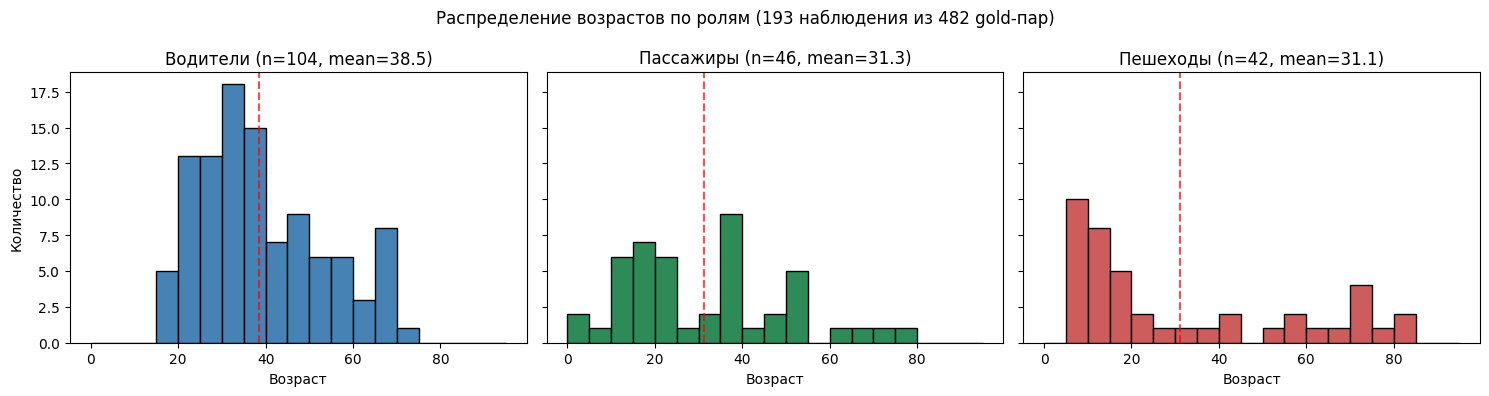

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

drivers = df_p[df_p['part_type'] == 'Водитель']['age']
passengers = df_p[df_p['part_type'] == 'Пассажир']['age']
pedestrians = df_ap['age']

bins = np.arange(0, 100, 5)
ax[0].hist(drivers, bins=bins, color='steelblue', edgecolor='black')
ax[0].set_title(f'Водители (n={len(drivers)}, mean={drivers.mean():.1f})')
ax[0].set_xlabel('Возраст')
ax[0].set_ylabel('Количество')
ax[0].axvline(drivers.mean(), color='red', linestyle='--', alpha=0.7)

ax[1].hist(passengers, bins=bins, color='seagreen', edgecolor='black')
ax[1].set_title(f'Пассажиры (n={len(passengers)}, mean={passengers.mean():.1f})')
ax[1].set_xlabel('Возраст')
ax[1].axvline(passengers.mean(), color='red', linestyle='--', alpha=0.7)

ax[2].hist(pedestrians, bins=bins, color='indianred', edgecolor='black')
ax[2].set_title(f'Пешеходы (n={len(pedestrians)}, mean={pedestrians.mean():.1f})')
ax[2].set_xlabel('Возраст')
ax[2].axvline(pedestrians.mean(), color='red', linestyle='--', alpha=0.7)

fig.suptitle('Распределение возрастов по ролям (193 наблюдения из 482 gold-пар)', fontsize=12)
fig.tight_layout()
fig.savefig('../data/processed/age_distribution.png', bbox_inches='tight')
plt.show()

**Наблюдения:**

- **Водители** — унимодальное распределение, пик 30-40 лет, mean=38.5 — соответствует средне-российскому возрасту водителя.
- **Пассажиры** — широкий разброс (3-77), включая детей и пожилых.
- **Пешеходы** — выраженно бимодальное: дети (5-15) и пожилые (60-83). Это хорошо известный РФ-паттерн: эти две группы наиболее уязвимы для ДТП-наездов.

## 2. Связь возраста водителей с тяжестью ДТП

In [5]:
drivers_df = df_p[df_p['part_type'] == 'Водитель'].copy()
by_severity = drivers_df.groupby('severity')['age'].agg(['count', 'mean', 'std']).round(1)
by_severity

,count,mean,std
severity,,,
dead,49,37.9,13.7
light,35,42.5,16.4
severe,19,32.8,11.3
severe_multiple,1,39.0,NaN


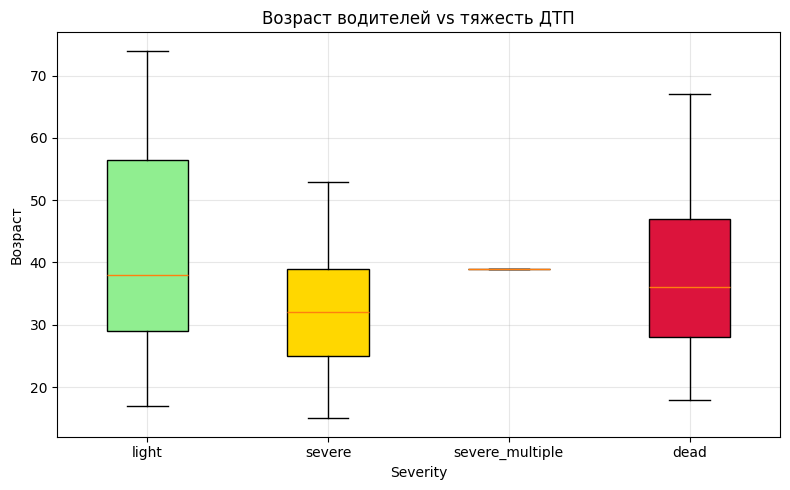

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
severity_order = ['light', 'severe', 'severe_multiple', 'dead']
data = [drivers_df[drivers_df['severity'] == s]['age'].values for s in severity_order]
bp = ax.boxplot(data, tick_labels=severity_order, patch_artist=True)
colors = ['lightgreen', 'gold', 'orange', 'crimson']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Возраст водителей vs тяжесть ДТП')
ax.set_xlabel('Severity')
ax.set_ylabel('Возраст')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('../data/processed/age_severity_drivers.png', bbox_inches='tight')
plt.show()

## 3. Связь возраста со стажем (только водители у которых есть оба поля)

Водителей с возрастом и стажем: 104 из 104


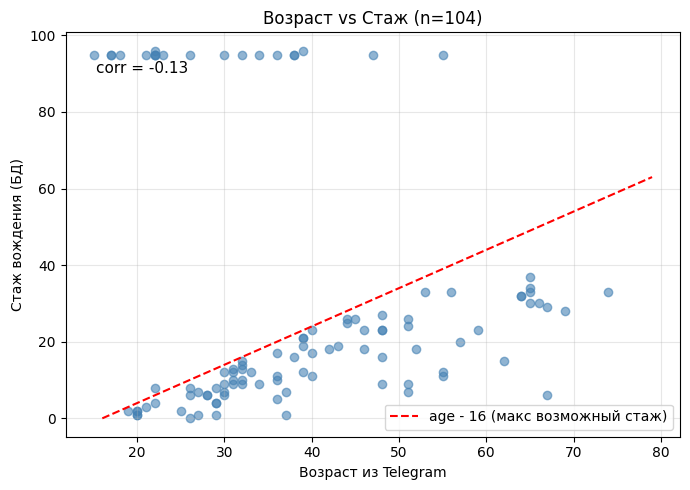

In [7]:
with_exp = drivers_df[drivers_df['driver_service_length'].notnull()].copy()
print(f'Водителей с возрастом и стажем: {len(with_exp)} из {len(drivers_df)}')
if len(with_exp) > 5:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(with_exp['age'], with_exp['driver_service_length'], alpha=0.6, color='steelblue')
    xs = np.arange(16, 80)
    ax.plot(xs, xs - 16, color='red', linestyle='--', label='age - 16 (макс возможный стаж)')
    ax.set_xlabel('Возраст из Telegram')
    ax.set_ylabel('Стаж вождения (БД)')
    ax.set_title(f'Возраст vs Стаж (n={len(with_exp)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    corr = with_exp[['age', 'driver_service_length']].corr().iloc[0, 1]
    ax.text(0.05, 0.9, f'corr = {corr:.2f}', transform=ax.transAxes, fontsize=11)
    fig.tight_layout()
    fig.savefig('../data/processed/age_vs_experience.png', bbox_inches='tight')
    plt.show()

Точки выше пунктирной линии «age - 16» — невозможны (стаж больше чем максимально возможный для возраста). Если есть — это аномалия в одной из сторон (NER ошибся или БД содержит неправдоподобный стаж).

## 4. Распределение по полу

In [8]:
all_with_age = pd.concat([df_p[['role', 'age', 'sex']], df_ap[['role', 'age', 'sex']]])
by_sex = all_with_age.groupby(['role', 'sex'])['age'].agg(['count', 'mean']).round(1)
by_sex

count  mean
role         sex                      
Велосипедист Мужской           1  10.0
Водитель     Женский          24  43.5
             Мужской          78  36.9
             Не определен      2  39.0
Пассажир     Женский          20  31.8
             Мужской          26  31.0
Пешеход      Женский          17  47.5
             Мужской          25  19.9

## 5. Сводка для нарратива

In [9]:
print('=' * 60)
print('СВОДКА ОБОГАЩЕНИЯ ВОЗРАСТАМИ')
print('=' * 60)
print(f'Всего назначено возрастов:     {len(df_p) + len(df_ap)}')
print(f'  Водители:                    {(df_p.part_type == "Водитель").sum()}')
print(f'  Пассажиры:                   {(df_p.part_type == "Пассажир").sum()}')
print(f'  Велосипедисты:               {(df_p.part_type.str.contains("Велосипед", na=False)).sum()}')
print(f'  Пешеходы:                    {len(df_ap)}')
print()
all_ages = pd.concat([df_p.age, df_ap.age])
print(f'Возраст: min={all_ages.min()}, max={all_ages.max()}, mean={all_ages.mean():.1f}')
print(f'Источник: 482 gold-пары пост↔ДТП → 384 с возрастами → 291 после фильтра мульти-ДТП')
print(f'Покрытие: 193/2879 = 6.7% от всех NER-возрастных меток в корпусе')

СВОДКА ОБОГАЩЕНИЯ ВОЗРАСТАМИ
Всего назначено возрастов:     193
  Водители:                    104
  Пассажиры:                   46
  Велосипедисты:               1
  Пешеходы:                    42

Возраст: min=3, max=83, mean=35.0
Источник: 482 gold-пары пост↔ДТП → 384 с возрастами → 291 после фильтра мульти-ДТП
Покрытие: 193/2879 = 6.7% от всех NER-возрастных меток в корпусе
